In [ ]:
!pip install nltk scikit-learn tensorflow --quiet

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import gdown

# The provided link was a Google Drive quota page, not a direct file link.
# Please replace the 'file_id' below with the actual ID from a shareable link of your dataset file.
# You can get this ID from a shareable Google Drive link (e.g., 'https://drive.google.com/file/d/FILE_ID/view').
file_id = '1AsTmpKHUiDNqNRpioYCmVk8ix-nrVoG8' # Replace with your dataset's file ID
output_filename = 'dataset.csv'

Mounted at /content/drive


In [ ]:
gdown.download(id=file_id, output=output_filename, quiet=False)
print(f"File downloaded as '{output_filename}'")

Downloading...
From (original): https://drive.google.com/uc?id=1AsTmpKHUiDNqNRpioYCmVk8ix-nrVoG8
From (redirected): https://drive.google.com/uc?id=1AsTmpKHUiDNqNRpioYCmVk8ix-nrVoG8&confirm=t&uuid=5fbc9b7c-4f95-4c37-a741-fd71501092d9
To: /content/dataset.csv
100%|██████████| 556M/556M [00:06<00:00, 83.7MB/s]

File downloaded as 'dataset.csv'


In [ ]:
!pip install pandas numpy nltk scikit-learn imbalanced-learn gdown tensorflow emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv("/content/dataset.csv")

display(df.head())
print(df.shape)

/tmp/ipykernel_10405/2720580128.py:3: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/dataset.csv")


,Title,Text,Subreddit,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(488738, 79)


In [ ]:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

In [ ]:
print(df.shape)
print(df.columns)
df.info()

(488738, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488738 entries, 0 to 488737
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488608 non-null  object
 1   Text       488573 non-null  object
 2   Subreddit  488535 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [ ]:
df = df.dropna()

print(df.isnull().sum())

Title        0
Text         0
Subreddit    0
dtype: int64


In [ ]:
valid_labels = [
    "depression",
    "mentalhealth",
    "Anxiety",
    "bipolar",
    "BPD",
    "schizophrenia",
    "autism"
]

# normalize text (very important)
df["Subreddit"] = df["Subreddit"].astype(str).str.strip()

# keep only valid labels
df = df[df["Subreddit"].isin(valid_labels)]

df = df[df["Subreddit"] != "mentalhealth"]

df["Subreddit"].value_counts()

,count
Subreddit,
depression,258490
Anxiety,86242
bipolar,41490
BPD,38210
schizophrenia,17505
autism,7142


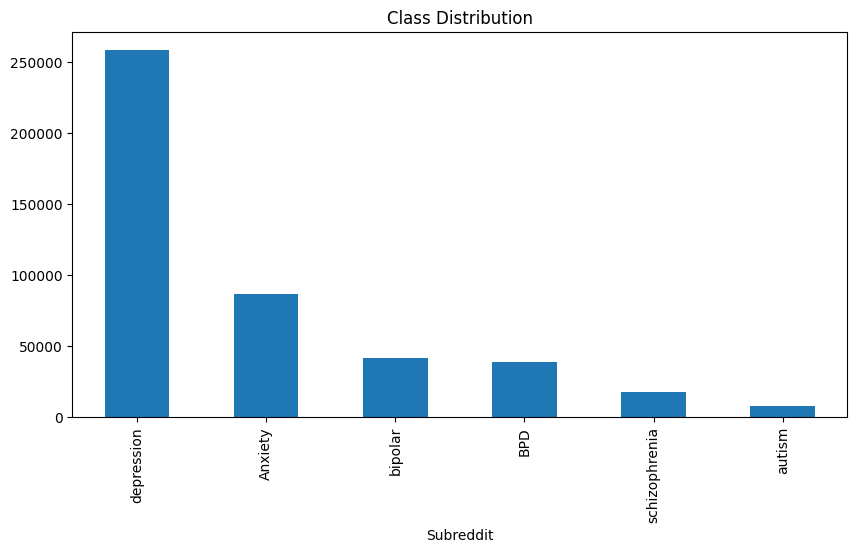

In [ ]:
import matplotlib.pyplot as plt

df["Subreddit"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Class Distribution")
plt.show()

In [ ]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

,text_length
count,449079.000000
mean,184.987488
std,224.415564
min,0.000000
25%,60.000000
50%,121.000000
75%,229.000000
max,6597.000000


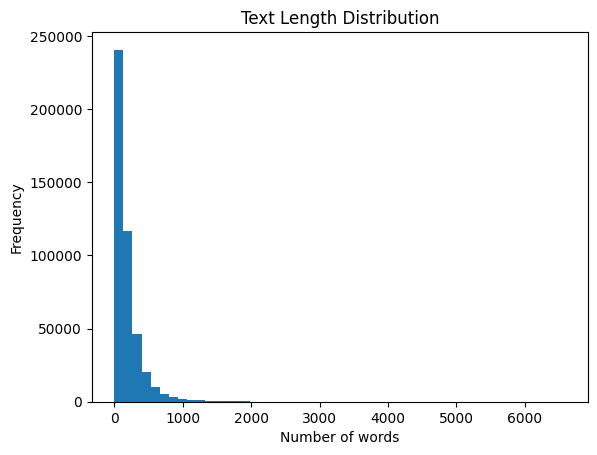

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df = df[df["text_length"] > 0]
print(df.shape)

(449000, 4)


In [ ]:
df["combined_text"] = df["Title"] + " " + df["Text"]

In [ ]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["combined_text"].apply(clean_text)

In [ ]:
MAX_WORDS = 300

df["clean_text"] = df["clean_text"].apply(
    lambda x: " ".join(x.split()[:MAX_WORDS])
)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_vocab = 20000
max_len = 150

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

X = tokenizer.texts_to_sequences(df["clean_text"])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df["Subreddit"])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from imblearn.over_sampling import SMOTE

# reshape for SMOTE (required)
nsamples, nx = X_train.shape
X_train_2d = X_train.reshape((nsamples, nx))

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_2d, y_train)

# reshape back
X_train_res = X_train_res.reshape((-1, max_len))

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_res))

Before SMOTE: [ 68984  30557   5710  33186 206762  14001]
After SMOTE : [206762 206762 206762 206762 206762 206762]


In [ ]:
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class CapsuleLayer(Layer):
    def __init__(self, num_capsule, dim_capsule, routings=3, **kwargs):
        super(CapsuleLayer, self).__init__(**kwargs)
        self.num_capsule = num_capsule
        self.dim_capsule = dim_capsule
        self.routings = routings

    def build(self, input_shape):
        self.input_dim = input_shape[-1]

        self.W = self.add_weight(
            shape=(1, self.input_dim, self.num_capsule * self.dim_capsule),
            initializer='glorot_uniform',
            trainable=True
        )

    def call(self, inputs):
        batch_size = K.shape(inputs)[0]

        # correct matmul
        u_hat = K.dot(inputs, self.W[0])

        # ✅ FIX: preserve batch dimension
        u_hat = K.reshape(
            u_hat,
            (batch_size, -1, self.num_capsule, self.dim_capsule)
        )

        # reduce sequence dimension
        u_hat = K.mean(u_hat, axis=1)

        return u_hat

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Flatten

input_layer = Input(shape=(max_len,))

x = Embedding(max_vocab, 64)(input_layer)

x = Bidirectional(LSTM(32, return_sequences=True))(x)

x = CapsuleLayer(num_capsule=10, dim_capsule=16)(x)

# now shape = (batch, 10, 16)
x = Flatten()(x)   # safe now ✅

x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(len(le.classes_), activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_9 (Embedding)         │ (None, 150, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 150, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capsule_layer_9 (CapsuleLayer)  │ (None, 10, 16)         │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,422 (5.04 MB)

 Trainable params: 1,320,422 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_res, y_train_res,
    epochs=2,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/2
8723/8723 ━━━━━━━━━━━━━━━━━━━━ 2250s 258ms/step - accuracy: 0.4772 - loss: 1.2827 - val_accuracy: 0.0016 - val_loss: 2.3538
Epoch 2/2
8723/8723 ━━━━━━━━━━━━━━━━━━━━ 2284s 262ms/step - accuracy: 0.5015 - loss: 1.2084 - val_accuracy: 0.0036 - val_loss: 2.3258


In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 92s 33ms/step


In [ ]:
from sklearn.metrics import f1_score, accuracy_score

results = []

for i, label in enumerate(le.classes_):

    y_true_bin = (y_test == i).astype(int)
    y_pred_bin = (y_pred == i).astype(int)

    class_f1 = f1_score(y_true_bin, y_pred_bin)
    non_class_f1 = f1_score(1 - y_true_bin, 1 - y_pred_bin)
    acc = accuracy_score(y_true_bin, y_pred_bin) * 100

    results.append([
        i,
        label,
        round(non_class_f1, 6),
        round(class_f1, 6),
        round(acc, 1)
    ])

result_df = pd.DataFrame(
    results,
    columns=["Class", "Label", "Non-Class F1", "Class F1", "Accuracy"]
)

print(result_df)

   Class          Label  Non-Class F1  Class F1  Accuracy
0      0        Anxiety      0.955940  0.806099      92.8
1      1            BPD      0.973782  0.666004      95.1
2      2         autism      0.991124  0.594384      98.3
3      3        bipolar      0.971397  0.690082      94.8
4      4     depression      0.822808  0.883754      86.0
5      5  schizophrenia      0.988182  0.645984      97.7


In [ ]:
overall_accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Overall model accuracy: {overall_accuracy:.2f}%")

Overall model accuracy: 82.33%


Confusion Matrix for Each Class:


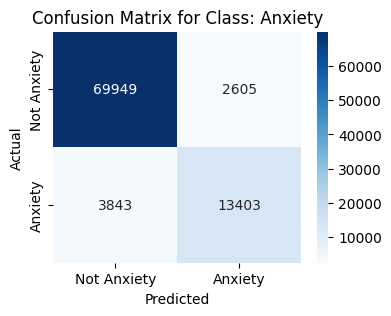

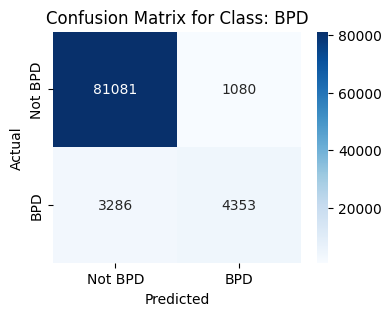

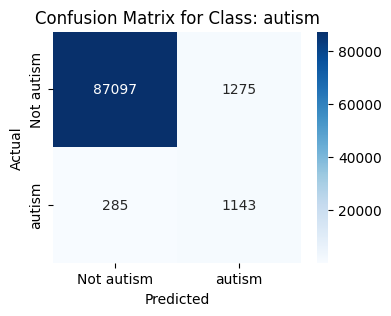

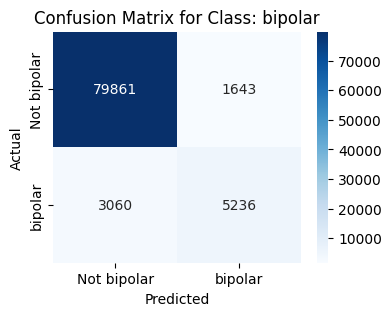

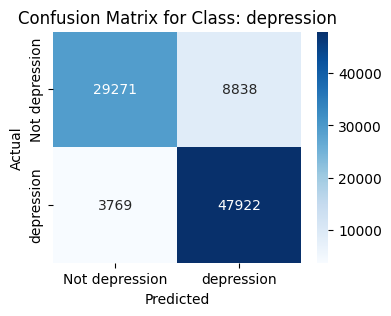

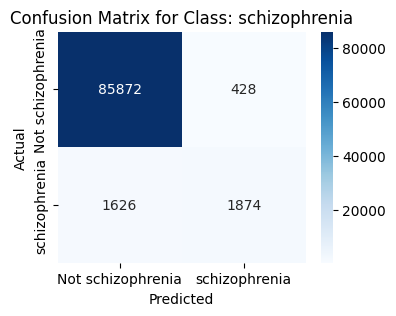


Overall Confusion Matrix:


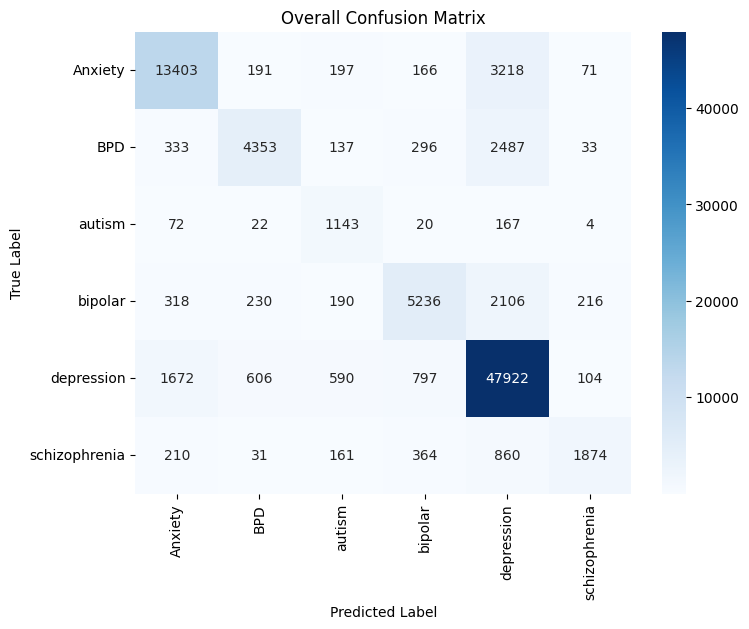

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for each class
print("Confusion Matrix for Each Class:")
for i, label in enumerate(le.classes_):
    y_true_bin = (y_test == i).astype(int)
    y_pred_bin = (y_pred == i).astype(int)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Not ' + label, label],
                yticklabels=['Not ' + label, label])
    plt.title(f"Confusion Matrix for Class: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Overall Confusion Matrix
print("\nOverall Confusion Matrix:")
overall_cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    overall_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title("Overall Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()